In [1]:
# PHASE 1: RISK ENGINE

In [2]:
# Calculating the log returns of the stocks within the portfolio

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import yfinance as yf

In [59]:
n = int(input("Enter the number of stocks in your portfolio: "))
tickers = []
weight = []

# Logging the stocks within the portfolio of the user; and the weightage each of them carries in the portfolio
# (I can ig optimize this by storing the stock and its weight in a pair)

for i in range(n):
    stock = input("Enter the stock in your portfolio: ")
    tickers.append(stock)
    wt = int(input("Enter its weightage within your portfolio: "))
    weight.append(wt)

total_weight = sum(weight)
if total_weight != 100:
    print(f"Warning: Your weights sum to {total_weight}%. Normalizing to 100%...")
    weight = [w / total_weight * 100 for w in weight]
print(tickers, weight)

ValueError: invalid literal for int() with base 10: ''

In [58]:
data = pd.DataFrame()

# Used a for loop to fetch all the sources,
# and made it (the comment and the code)
# multi-line to avoid getting flagged by Ruff

for ticker in tickers:
    data[ticker] = yf.download(
        ticker,
        start="2015-01-01",
        auto_adjust=False,
    )["Adj Close"]

data.dropna()
data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,MRNA,LULU,NKE
Date,,,,
2015-01-02,24.171762,NaN,55.340000,40.316383
2015-01-05,23.490799,NaN,55.959999,39.667286
2015-01-06,23.493010,NaN,55.570000,39.433949
2015-01-07,23.822437,NaN,57.650002,40.248516
2015-01-08,24.737741,NaN,59.070000,41.177616


In [60]:
log_returns_of_portfolio = pd.DataFrame()
column_list = data.columns.tolist()

# Calculated the Log Return
# Not simple return coz,
# simple return = Single portfolio comparison
# log return = multiple portfolio comparsion

for ticker in column_list:
    log_returns_of_portfolio[ticker] = np.log(data[ticker] / data[ticker].shift(1))

log_returns_clean = log_returns_of_portfolio.dropna()
log_returns_of_portfolio.head()

,AAPL,MRNA,LULU,NKE
Date,,,,
2015-01-02,NaN,NaN,NaN,NaN
2015-01-05,-0.028576,NaN,0.011141,-0.016231
2015-01-06,0.000094,NaN,-0.006994,-0.005900
2015-01-07,0.013925,NaN,0.036747,0.020446
2015-01-08,0.037702,NaN,0.024333,0.022822


In [7]:
# Annualization of the data

In [8]:
annualized_return = pd.DataFrame(index=["Annualized Return"])

for ticker in column_list:
    mean_daily_log_return = log_returns_of_portfolio[ticker].mean()

    # recently learnt should prefer 252 over 250
    # for number of trading days within a year
    annualized_return[ticker] = np.exp(mean_daily_log_return * 252) - 1

print(annualized_return)

                       AAPL      MRNA      LULU       NKE
Annualized Return  0.250353  0.347894  0.045687 -0.014076


In [9]:
# calculating standard deviation, variance, covariance and correlation

In [10]:
# Just now learnt the concept of "VECTORIZATION".
# Thanks to vectorization, we do not require to loop through
# all the stocks in the portfolio and calculate the variance individually,
# but rather can do the task within one single statement

# THEREFORE,

annualized_variance_of_stocks = log_returns_of_portfolio.var() * 252
annualized_standard_deviation_of_stocks = log_returns_of_portfolio.std() * np.sqrt(252)
annualized_covariance_of_stocks = log_returns_of_portfolio.cov() * 252
# Correlation is a unitless ratio and thus doesn't require to be multiplied with 250
annualized_correlation_of_stocks = log_returns_of_portfolio.corr()

print(f"Annualized std deviation: {annualized_standard_deviation_of_stocks}\n")
print(f"Annualized variance: {annualized_variance_of_stocks}\n")
print(f"Annualized covariance: {annualized_covariance_of_stocks}\n")
print(f"Annualized correlation: {annualized_correlation_of_stocks}\n")

Annualized std deviation: AAPL    0.286774
MRNA    0.809745
LULU    0.410715
NKE     0.314503
dtype: float64

Annualized variance: AAPL    0.082239
MRNA    0.655687
LULU    0.168687
NKE     0.098912
dtype: float64

Annualized covariance:           AAPL      MRNA      LULU       NKE
AAPL  0.082239  0.042334  0.042296  0.038518
MRNA  0.042334  0.655687  0.053171  0.041417
LULU  0.042296  0.053171  0.168687  0.061454
NKE   0.038518  0.041417  0.061454  0.098912

Annualized correlation:           AAPL      MRNA      LULU       NKE
AAPL  1.000000  0.170206  0.359107  0.427071
MRNA  0.170206  1.000000  0.154249  0.146905
LULU  0.359107  0.154249  1.000000  0.475760
NKE   0.427071  0.146905  0.475760  1.000000



In [11]:
# variance of the portfolio

In [12]:
# variance of a portfoliio, i.e.,
# ((omega1 * sigma1) + (omega2 * sigma2))^2
# =   (omega1^2 * sigma1^2) +
#     (omega2^2 * sigma2^2) +
#     (2 * omega1 * omega2 * sigma1 * sigma2)

# WHERE, omega1 = weightage of stock1 in the portfolio
#        omega2 = weightage of stock2 in the portfolio
#        sigma1 = standard deviation of stock1
#        sigma2 = standard deviation of stock

# BUT, in this scenario, we have the annual standard deviation collectively
# and thus, we can apply the formula:

# Portfolio variance = omega^T * Sigma(Σ) * omega

# WHERE,  omega = vector of weights
#         omega^T = Transposed vector of those weights
#         Sigma (Σ) = Covariance matrix (here, annualized_covariance_of_stocks)

In [13]:
weights_array = np.array(weight) / 100  # divided by 100 to get the decimal values
variance_of_portfolio = np.dot(weights_array.T, np.dot(annualized_covariance_of_stocks, weights_array))
print(f"Variance of the portfolio is: {variance_of_portfolio}")

Variance of the portfolio is: 0.17505864133282598


In [14]:
# Calculating the portfolio return

# Portfolio return = omega1 * R1 + omega2 * R2 + .....

# OR

# Portfolio return = omega^T dot-product R

# WHERE,  omega1 = weight of stock1,
#         omega2 = weight of stock2, ...
#         omega = weights vector
#         omega^T = Transposed vector of weights vector
#         R1 = return of stock1
#         R2 = return of stock2, ...
#         R = returns vector

In [15]:
individual_returns = annualized_return.iloc[0]
portfolio_return = np.dot(weights_array.T, individual_returns)
print(f"Annual portfolio return: {portfolio_return}")

Annual portfolio return: 0.22388224153760183


In [16]:
# Sharpe Ratio

# Sharpe ratio = (risk-free rate - excess return of stock "i") / standard deviation of stock "i"

# Other way to calculate Sharpe Ratio is:
#     Sharpe Ratio = (portfolio return - risk-free rate) / portfolio  volatility
#
# (portfolio volatility = sqrt of the variance of the portfolio)

In [17]:
us_treasury_yield = yf.download("^TNX", period="5d", auto_adjust=False)["Adj Close"]
# Cause we take risk free rate as the current yield on a 10 year US Treasury bond

risk_free_rate = float(us_treasury_yield.iloc[-1].iloc[0]) / 100
print("Current risk-free rate: ", risk_free_rate)

[*********************100%***********************]  1 of 1 completed

Current risk-free rate:  0.0527299976348877


In [18]:
sharpe_ratio = (portfolio_return - risk_free_rate) / np.sqrt(variance_of_portfolio)
print("Sharpe ratio of the portfolio is: ", sharpe_ratio)

Sharpe ratio of the portfolio is:  0.4090635854296346


In [19]:
# PHASE 2: PORTFOLIO OPTIMIZATION THEORY

In [20]:
# Markowitz Portfolio Optimization Theory
# Also calculating the variance and sharpe on each simulation

In [21]:
portfolio_returns = []
portfolio_volatilites = []

max_sharpe = -np.inf
max_sharpe_weights = None

min_variance = np.inf
min_variance_weights = None

for x in range(10000):
    # Calculating the random weights to uuse in the markowitz portfolio optimization theory
    new_weights = np.random.random(n)
    new_weights /= np.sum(new_weights)

    # Calculating and updating the minimum variance during the 10000 simulations
    variance_of_simulation = np.dot(new_weights.T, np.dot(annualized_covariance_of_stocks, new_weights))
    if variance_of_simulation < min_variance:
        min_variance = min(min_variance, variance_of_simulation)
        min_variance_weights = new_weights.copy()

    # Calculating and adding the portfolio returns and volatilities across the 10000 simulations
    portfolio_returns.append(np.sum(new_weights * log_returns_of_portfolio.mean()) * 252)
    portfolio_volatilites.append(np.sqrt(variance_of_simulation))

    # Calculating the sharpe for the simulations and updating the max sharpe
    sharpe_of_simulation = (portfolio_returns[x] - risk_free_rate) / portfolio_volatilites[x]
    if max_sharpe < sharpe_of_simulation:
        max_sharpe = max(max_sharpe, sharpe_of_simulation)
        max_sharpe_weights = new_weights.copy()

portfolio_returns = np.array(portfolio_returns)
portfolio_volatilites = np.array(portfolio_volatilites)

print("Expected portfolio returns: ", portfolio_returns)
print("Expected portfolio volatilies: ", portfolio_volatilites)
print("Max Sharpe: ", max_sharpe)
print("Minimum variance: ", min_variance)

Expected portfolio returns:  [0.09546456 0.13063495 0.14952448 ... 0.10550021 0.14999918 0.15011944]
Expected portfolio volatilies:  [0.34020435 0.36986802 0.33536381 ... 0.26704882 0.33822049 0.30599172]
Max Sharpe:  0.6076539191768341
Minimum variance:  0.06198124341149736


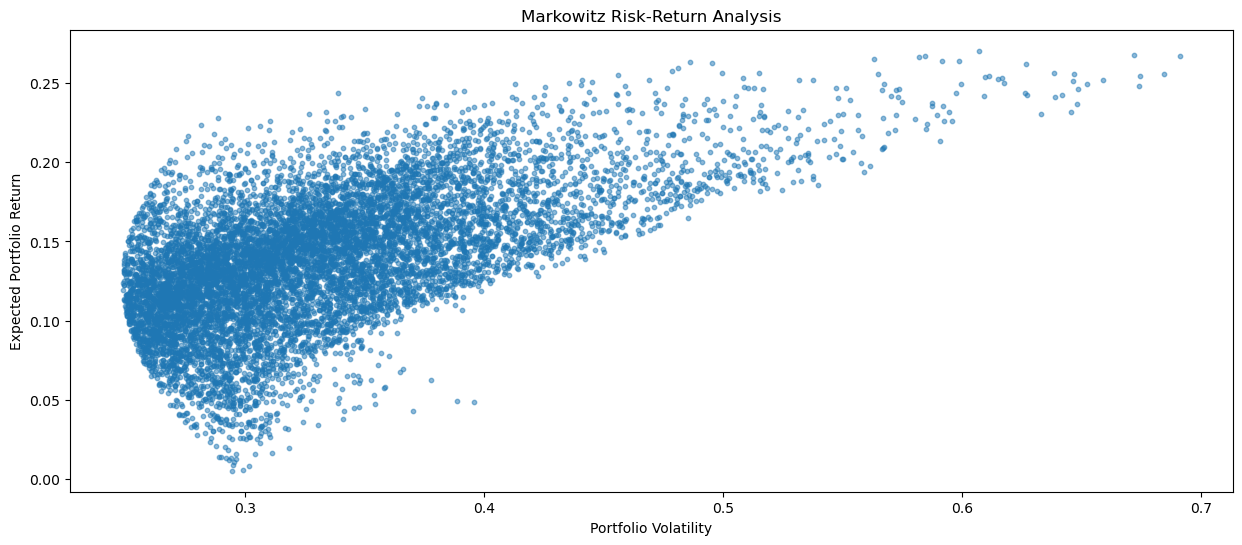

In [22]:
# Calculating the efficient frontier
plt.figure(figsize=(15, 6))
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.5)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Risk-Return Analysis")

plt.show()

In [23]:
sorted_indices = np.argsort(portfolio_volatilites)

sorted_volatilities = portfolio_volatilites[sorted_indices]

sorted_returns = portfolio_returns[sorted_indices]

max_return_so_far = np.maximum.accumulate(sorted_returns)

efficient_mask = sorted_returns >= max_return_so_far

efficient_volatilities = sorted_volatilities[efficient_mask]

efficient_returns = sorted_returns[efficient_mask]

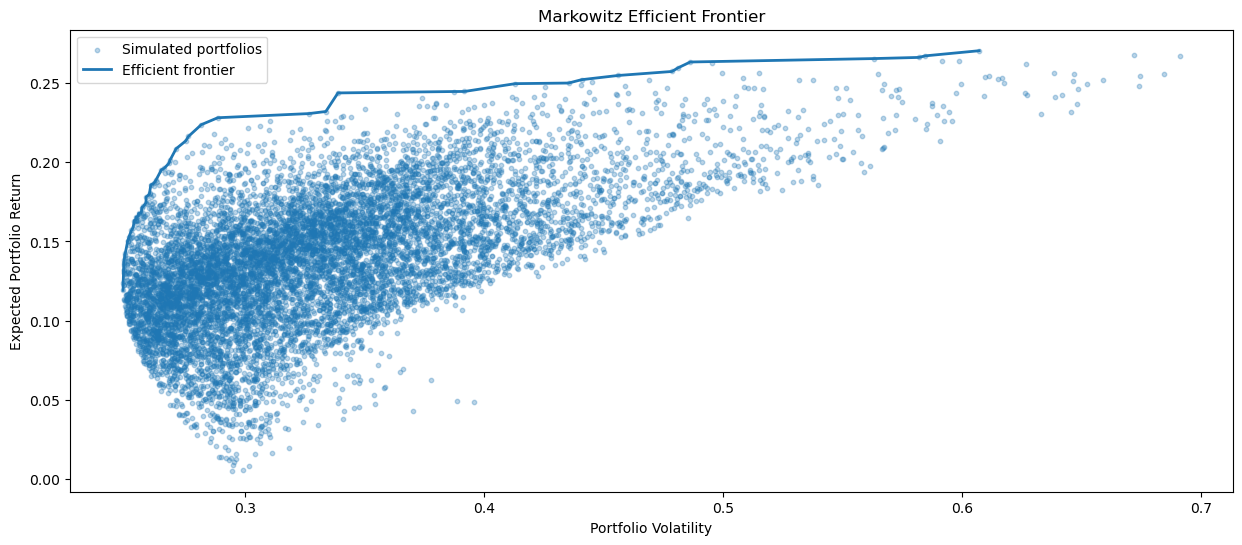

In [24]:
plt.figure(figsize=(15, 6))

# All simulated portfolios
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.3, label="Simulated portfolios")

# Efficient frontier
plt.plot(efficient_volatilities, efficient_returns, linewidth=2, label="Efficient frontier")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()

plt.show()

In [25]:
# CAPM

# beta = covariance with market / (variance of the market) ^ 2


In [26]:
# Using the S&P 500 as the market benchmark

market_data = yf.download(
    "^GSPC",
    start="2015-01-01",
    auto_adjust=False,
)["Adj Close"]

market_data = market_data.squeeze()  # converts the dataframe with one column to a panda series

market_returns = np.log(market_data / market_data.shift(1)).dropna()

market_returns.name = "MARKET"

market_returns.head()

[*********************100%***********************]  1 of 1 completed


Date
2015-01-05   -0.018447
2015-01-06   -0.008933
2015-01-07    0.011563
2015-01-08    0.017730
2015-01-09   -0.008439
Name: MARKET, dtype: float64

In [27]:
# Calculate covariance of each stock with the market

returns_with_market = pd.concat(
    [
        log_returns_of_portfolio,
        market_returns,
    ],
    axis=1,
).dropna()

covariance_matrix_with_market = returns_with_market.cov()

covariance_with_market = covariance_matrix_with_market["MARKET"].drop("MARKET")

market_variance = market_returns.var()

beta = covariance_with_market / market_variance

print("Covariance with market:")
print(covariance_with_market)

print("\nMarket variance:")
print(market_variance)

print("\nBeta:")
print(beta)

Covariance with market:
AAPL    0.000179
MRNA    0.000123
LULU    0.000179
NKE     0.000154
Name: MARKET, dtype: float64

Market variance:
0.00012404129560986805

Beta:
AAPL    1.444891
MRNA    0.988471
LULU    1.439218
NKE     1.240874
Name: MARKET, dtype: float64


In [28]:
# Calculate annualized historical market return
# and risk premium and the CAPM expected return

annualized_market_return = market_returns.mean() * 252

print(f"Annualized market return: {annualized_market_return:.2%}")

market_risk_premium = annualized_market_return - risk_free_rate

capm_expected_return = risk_free_rate + beta * market_risk_premium

print("CAPM expected return:")
print(capm_expected_return)

Annualized market return: 11.38%
CAPM expected return:
AAPL    0.140944
MRNA    0.113079
LULU    0.140598
NKE     0.128488
Name: MARKET, dtype: float64


In [29]:
# Convert annual risk-free rate to an approximate daily rate

daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1

# Calculate daily excess returns
stock_excess_returns = returns_with_market.drop(columns="MARKET") - daily_risk_free_rate
market_excess_returns = returns_with_market["MARKET"] - daily_risk_free_rate

In [30]:
# Run CAPM regression for each stock
regression_results = {}

for stock in stock_excess_returns.columns:
    X = sm.add_constant(market_excess_returns)
    y = stock_excess_returns[stock]

    model = sm.OLS(y, X).fit()

    regression_results[stock] = model

In [31]:
# Extract regression statistics
alpha = pd.Series({stock: regression_results[stock].params["const"] for stock in regression_results})

regression_beta = pd.Series({stock: regression_results[stock].params["MARKET"] for stock in regression_results})

r_squared = pd.Series({stock: regression_results[stock].rsquared for stock in regression_results})

print("Regression alpha:")
print(alpha)

print("\nRegression beta:")
print(regression_beta)

print("\nR²:")
print(r_squared)

Regression alpha:
AAPL    0.000459
MRNA    0.000697
LULU   -0.000718
NKE    -0.000889
dtype: float64

Regression beta:
AAPL    1.186356
MRNA    0.811604
LULU    1.181698
NKE     1.018844
dtype: float64

R²:
AAPL    0.567914
MRNA    0.038245
LULU    0.293356
NKE     0.326000
dtype: float64


In [32]:
# Compare beta calculated from covariance with regression beta
beta_comparison = pd.DataFrame(
    {
        "Covariance Beta": beta,
        "Regression Beta": regression_beta,
    }
)

beta_comparison["Difference"] = beta_comparison["Covariance Beta"] - beta_comparison["Regression Beta"]

beta_comparison

,Covariance Beta,Regression Beta,Difference
AAPL,1.444891,1.186356,0.258535
MRNA,0.988471,0.811604,0.176868
LULU,1.439218,1.181698,0.257520
NKE,1.240874,1.018844,0.222030


In [33]:
# Calculate annualized historical returns for each stock
annualized_stock_returns = log_returns_of_portfolio.mean() * 252

return_comparison = pd.DataFrame(
    {
        "Historical Return": annualized_stock_returns,
        "CAPM Expected Return": capm_expected_return,
    }
)

return_comparison["Difference"] = return_comparison["Historical Return"] - return_comparison["CAPM Expected Return"]

return_comparison

,Historical Return,CAPM Expected Return,Difference
AAPL,0.223426,0.140944,0.082482
MRNA,0.298543,0.113079,0.185465
LULU,0.044674,0.140598,-0.095923
NKE,-0.014176,0.128488,-0.142664


In [34]:
# Calculate regression residuals
residuals = pd.DataFrame(index=returns_with_market.index)

for stock in stock_excess_returns.columns:
    residuals[stock] = regression_results[stock].resid

residuals.head()

# Summarize residual behavior
residual_summary = pd.DataFrame(
    {
        "Mean Residual": residuals.mean(),
        "Residual Std Dev": residuals.std(),
        "Min Residual": residuals.min(),
        "Max Residual": residuals.max(),
    }
)

residual_summary

,Mean Residual,Residual Std Dev,Min Residual,Max Residual
AAPL,4.235337e-19,0.012719,-0.085084,0.090077
MRNA,-1.185894e-18,0.050024,-0.262154,1.016292
LULU,4.517693e-19,0.022542,-0.232037,0.145280
NKE,6.211828e-19,0.018006,-0.217842,0.141878


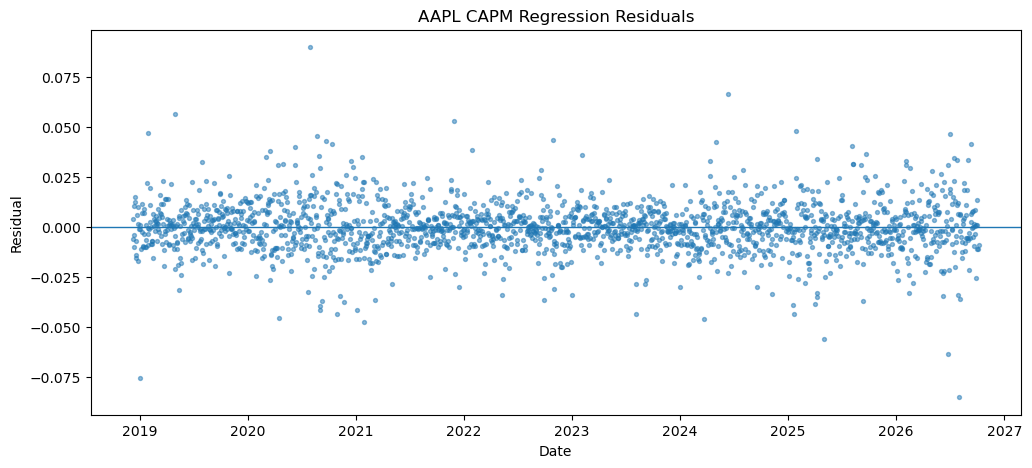

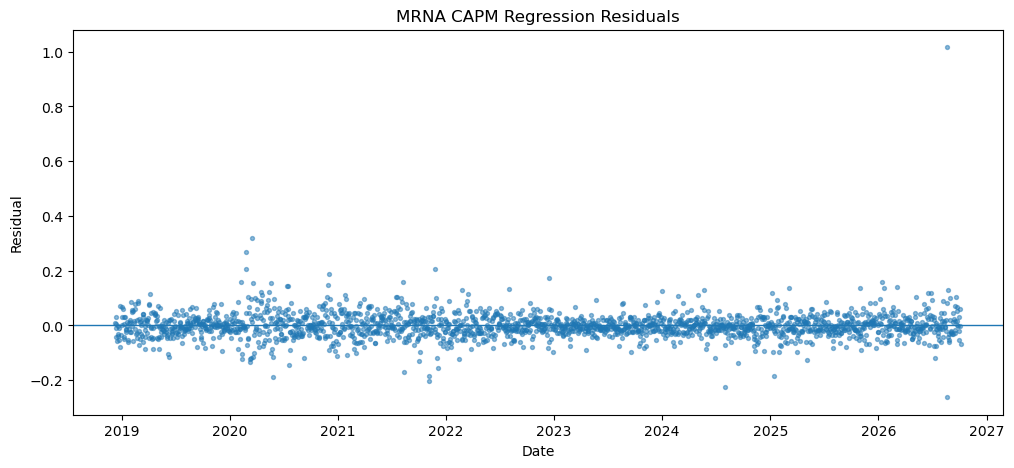

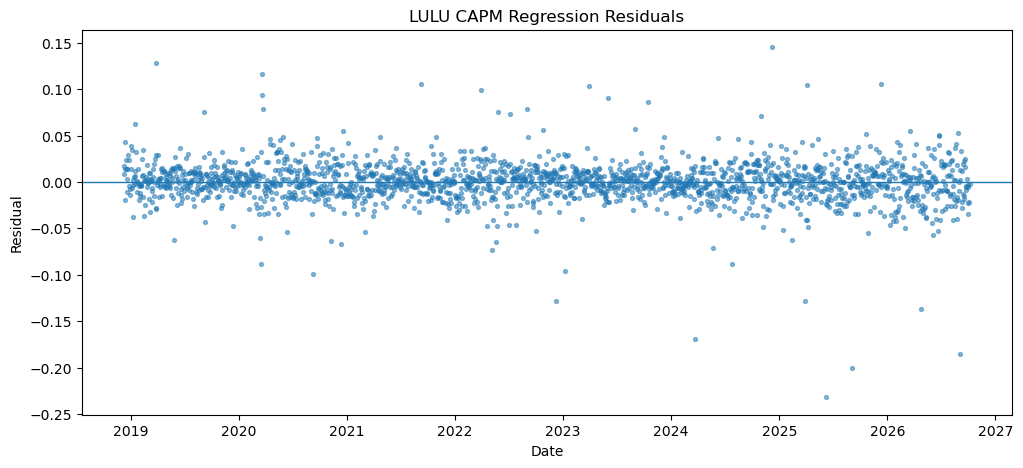

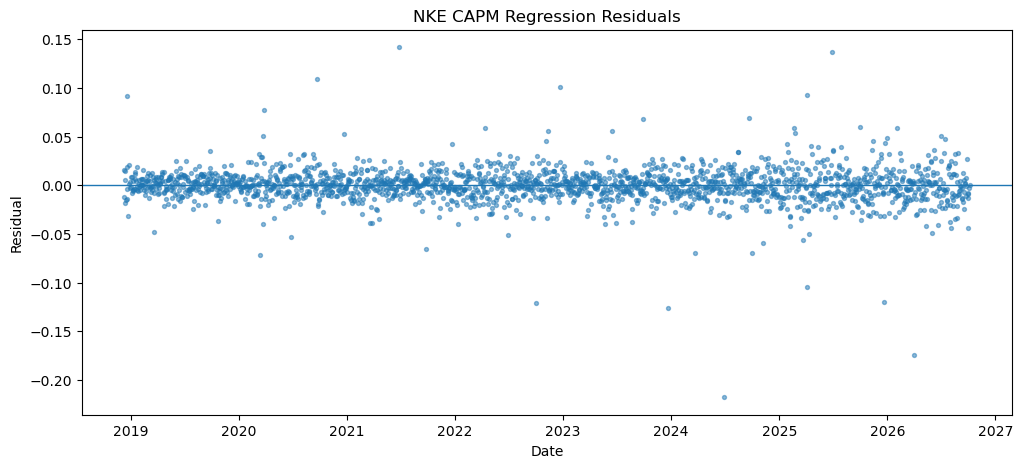

In [35]:
# Plot residuals over time
for stock in residuals.columns:
    plt.figure(figsize=(12, 5))

    plt.scatter(
        residuals.index,
        residuals[stock],
        s=8,
        alpha=0.5,
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"{stock} CAPM Regression Residuals")

    plt.show()

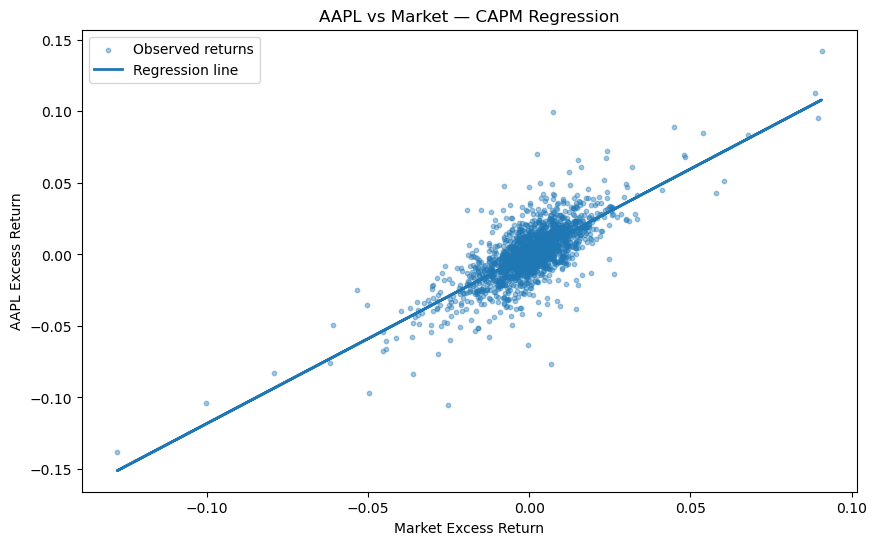

In [36]:
# Visualize the CAPM regression for AAPL
stock = "AAPL"

model = regression_results[stock]

plt.figure(figsize=(10, 6))

plt.scatter(
    market_excess_returns,
    stock_excess_returns[stock],
    s=10,
    alpha=0.4,
    label="Observed returns",
)

plt.plot(
    market_excess_returns,
    model.predict(sm.add_constant(market_excess_returns)),
    linewidth=2,
    label="Regression line",
)

plt.xlabel("Market Excess Return")
plt.ylabel(f"{stock} Excess Return")
plt.title(f"{stock} vs Market — CAPM Regression")
plt.legend()

plt.show()

In [37]:
# PHASE 4- MONTE CARLO SIMULATIONS

In [38]:
revenue_mean = log_returns_of_portfolio.mean()
revenue_std_deviation = log_returns_of_portfolio.std()
iterations = 1000

revenue = np.random.normal(loc=revenue_mean, scale=revenue_std_deviation, size=(iterations, len(log_returns_of_portfolio.columns)))
print(revenue)

[[-0.00361171  0.07686381  0.00961778 -0.00966326]
 [-0.00969685  0.01375767 -0.00309685  0.03933432]
 [-0.011685    0.01771135 -0.01329669 -0.01944222]
 ...
 [ 0.03718893 -0.01069272 -0.0258171   0.03524198]
 [ 0.005526   -0.02835044 -0.0177575  -0.01237835]
 [ 0.02401522 -0.01149839  0.00522609 -0.02430214]]


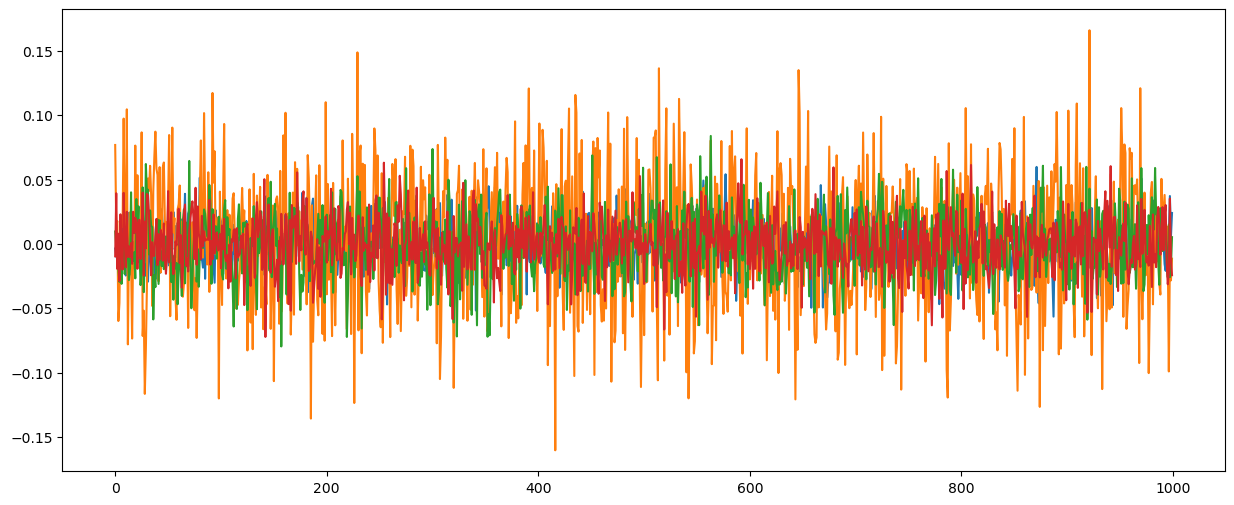

In [39]:
plt.figure(figsize=(15, 6))
plt.plot(revenue)
plt.show()

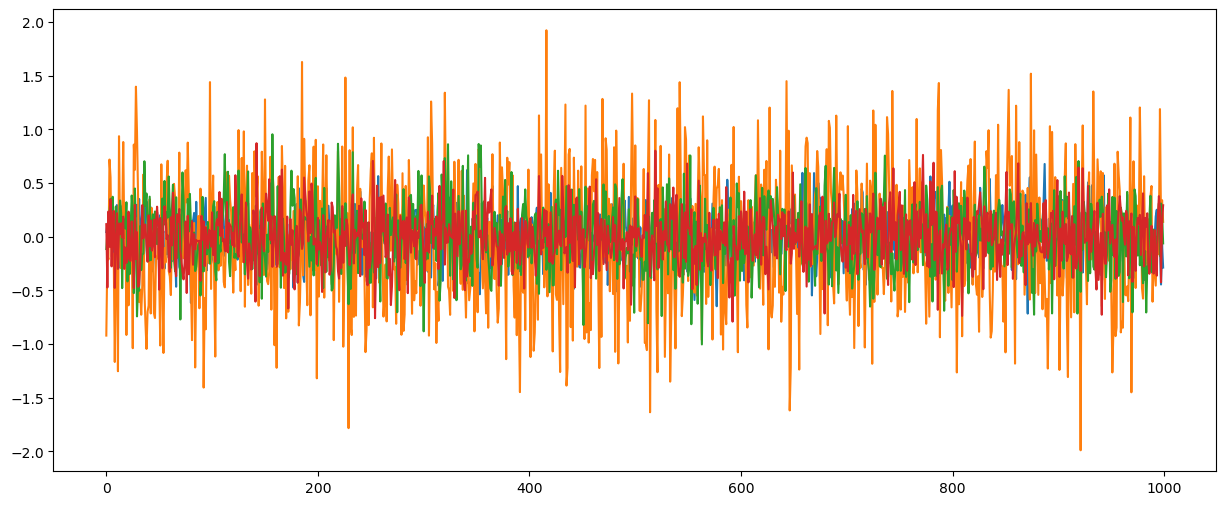

In [40]:
cogs_percentage = int(input("Enter the % of company's revenue that COGS amounts to: "))
cost_of_goods_sold = -(revenue * np.random.normal(cogs_percentage, revenue_std_deviation))

plt.figure(figsize=(15, 6))
plt.plot(cost_of_goods_sold)
plt.show()

In [41]:
gross_profit = revenue + cost_of_goods_sold
print(gross_profit)

[[ 0.03964686 -0.84424582 -0.10544178  0.10661921]
 [ 0.10644548 -0.15110951  0.03395139 -0.43399373]
 [ 0.12827007 -0.19453543  0.14577448  0.21451501]
 ...
 [-0.40823494  0.11744514  0.28303851 -0.38884104]
 [-0.06066071  0.31139157  0.19467935  0.13657602]
 [-0.26362283  0.12629444 -0.05729472  0.2681368 ]]


In [42]:
# Price today = Price yesterday * e^( drift + random value )

# WHERE,  drift = (mu - 1/2 (sigma)^2 )
# r = ln(price today/ price yesterday)
# and e^r is a random variable;
# (one of the components of the brownian motion)


# Another formula for drift is:
#         drift = mu - 1/2 * var

# WHERE, var = variance

# daily returns = e^r
# r = drift + std * z


In [43]:
# 1. Calculate the daily mean return for each stock
daily_mu = log_returns_of_portfolio.mean()

# 2. Calculate the daily variance for each stock
daily_var = log_returns_of_portfolio.var()

# 3. Calculate daily drift using strictly daily metrics
drift = daily_mu - (0.5 * daily_var)

print("Daily Drift:\n", drift)

Daily Drift:
 AAPL    0.000723
MRNA   -0.000116
LULU   -0.000157
NKE    -0.000253
dtype: float64


In [44]:
time_interval_of_forecast = 10000
forecast_iterations = 50
num_assets = len(drift)

# Generate random standard normal variables directly
Z = np.random.normal(0, 1, (time_interval_of_forecast, forecast_iterations, num_assets))

# Calculate daily standard deviation from the annualized version
daily_std = annualized_standard_deviation_of_stocks.values / np.sqrt(252)

# Calculate daily returns using geometric brownian motion
daily_returns = np.exp(drift.values + daily_std * Z)

print(daily_returns)

[[[0.98164492 0.97792455 0.9804729  0.9847605 ]
  [0.97311245 0.96501039 1.01429556 1.0261419 ]
  [1.05244998 1.09694972 1.06472426 1.01323585]
  ...
  [0.99554279 0.94631199 1.00714387 1.04214323]
  [1.01408737 0.9581777  0.98688259 0.97456437]
  [1.01499994 0.95825788 0.96142372 1.02275066]]

 [[0.99635696 1.08162434 0.97259276 1.04767737]
  [1.00447062 0.93654929 0.97224518 1.00070584]
  [1.00936147 0.96976513 1.03685726 0.97496584]
  ...
  [1.00900153 0.9047066  1.0048722  0.98991005]
  [1.00266676 1.02945814 0.99886358 1.00007992]
  [1.00862426 1.00999015 1.02716334 1.01730448]]

 [[0.99981573 1.11058447 1.00926031 1.02591282]
  [0.97534486 0.98514902 1.0507795  0.99626843]
  [0.97088634 1.0547537  0.97915609 1.01210089]
  ...
  [1.02409127 1.02227551 1.01998371 1.01991319]
  [1.01595924 1.08081538 0.9739251  0.9920279 ]
  [1.02299975 1.08396055 1.00237453 1.00692936]]

 ...

 [[1.00260079 0.97088247 1.02067968 1.01698319]
  [1.02738993 0.93232162 0.95555437 0.97808808]
  [1.00362

In [45]:
# Stock price of 'i'th day = Stock price of (i-1)th day * daily return of 'i'th day
# Therefore,

# Get the most recent prices
s0 = data.iloc[-1]
print("Initial stock price:\n", s0)

# Create an empty array matching the shape of daily_returns
price_list = np.zeros_like(daily_returns)

# Set the first day's price to the current actual price
price_list[0] = s0.values

# Loop through the remaining 9,999 days to calculate future prices
for t in range(1, time_interval_of_forecast):
    price_list[t] = price_list[t - 1] * daily_returns[t]

print("Final price list:\n", price_list)

Initial stock price:
 AAPL    332.290009
MRNA    191.000000
LULU     93.459999
NKE      34.139999
Name: 2026-10-06 00:00:00, dtype: float64
Final price list:
 [[[3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]
  [3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]
  [3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]
  ...
  [3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]
  [3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]
  [3.32290009e+02 1.91000000e+02 9.34599991e+01 3.41399994e+01]]

 [[3.31079461e+02 2.06590249e+02 9.08985188e+01 3.57677047e+01]
  [3.33775552e+02 1.78880914e+02 9.08660336e+01 3.41640968e+01]
  [3.35400733e+02 1.85225140e+02 9.69046784e+01 3.32853331e+01]
  ...
  [3.35281129e+02 1.72798961e+02 9.39153553e+01 3.37955285e+01]
  [3.33176145e+02 1.96626504e+02 9.33537895e+01 3.41427277e+01]
  [3.35155763e+02 1.92908119e+02 9.59986852e+01 3.47307743e+01]]

 [[3.31018452e+02 2.29435923e+02 9.17402677e+01 3.6694546

In [46]:
import numpy as np
import pandas as pd

# 1. Extract the terminal prices (taking the very last row across all 50 iterations for all assets)
terminal_prices = price_list[-1]

# Convert to a pandas DataFrame for easier readability and labeling
# Assuming columns match your asset order: [AAPL, NKE, LULU]
terminal_df = pd.DataFrame(terminal_prices, columns=data.columns)

print("Terminal price summary")

# 2. Compute key statistical metrics across the simulation iterations
summary_stats = pd.DataFrame(
    {
        "Mean Price": terminal_df.mean(),
        "Median Price": terminal_df.median(),
        "5th Percentile (Worst Case)": terminal_df.quantile(0.05),
        "95th Percentile (Best Case)": terminal_df.quantile(0.95),
        "Standard Deviation": terminal_df.std(),
    }
)

print(summary_stats.to_string())

# 3. Optional: Quick look at the raw terminal prices of the first few iterations
print("\nFirst 5 Terminal Price Iterations:\n", terminal_df.head())

Terminal price summary
        Mean Price   Median Price  5th Percentile (Worst Case)  95th Percentile (Best Case)  Standard Deviation
AAPL  1.644054e+06  631636.317412                 52968.807721                 5.869465e+06        2.383245e+06
MRNA  9.576928e+03      39.093772                     0.022496                 6.266910e+04        2.670485e+04
LULU  2.514657e+02      18.025349                     0.343742                 1.916358e+03        6.716680e+02
NKE   1.128121e+01       2.690833                     0.104088                 5.562433e+01        2.679152e+01

First 5 Terminal Price Iterations:
            AAPL          MRNA        LULU       NKE
0  5.000347e+06    158.482592    1.222647  0.241794
1  4.583175e+05     17.743611  148.711258  1.698340
2  3.194965e+06    434.423116  211.517750  3.803890
3  9.305419e+05   1986.144162   77.162899  3.261799
4  6.842995e+04  28576.540655   10.022801  0.310008


In [47]:
# 1. Dynamically create weights based on the number of columns (assets) in your data
num_assets = len(data.columns)

# Example: Equal weighting across all assets (e.g., 33.3% each for 3 assets, or 20% each for 5 assets)
# You can also customize this array to accept any custom user input weights as long as they sum to 1.0
weights = np.array([1.0 / num_assets] * num_assets)

print(f"Using dynamic weights for {num_assets} assets: {weights}")

# 2. Calculate the total portfolio value across all time steps and iterations
# price_list shape is (10000, 50, num_assets) -> dot product with weights gives shape (10000, 50)
portfolio_paths = np.dot(price_list, weights)

# 3. Extract the terminal portfolio values (the final day for all iterations)
terminal_portfolio_values = portfolio_paths[-1]

# 4. Define scenario thresholds using percentiles
bull_threshold = np.percentile(terminal_portfolio_values, 90)  # Top 10%
bear_threshold = np.percentile(terminal_portfolio_values, 10)  # Bottom 10%

# 5. Filter the paths into respective scenarios dynamically
bull_paths = portfolio_paths[:, terminal_portfolio_values >= bull_threshold]
bear_paths = portfolio_paths[:, terminal_portfolio_values <= bear_threshold]
base_paths = portfolio_paths[:, (terminal_portfolio_values > bear_threshold) & (terminal_portfolio_values < bull_threshold)]

print("Scenario analysis summary:")
print(f"Total Iterations: {portfolio_paths.shape[1]}")
print(f"Bull Market Scenarios (Top 10%): {bull_paths.shape[1]} paths")
print(f"Base Case Scenarios (Middle 80%): {base_paths.shape[1]} paths")
print(f"Bear Market Scenarios (Bottom 10%): {bear_paths.shape[1]} paths")

print(f"\nAverage Terminal Value - Bull Case: ${bull_paths[-1].mean():,.2f}")
print(f"Average Terminal Value - Base Case: ${base_paths[-1].mean():,.2f}")
print(f"Average Terminal Value - Bear Case: ${bear_paths[-1].mean():,.2f}")

Using dynamic weights for 4 assets: [0.25 0.25 0.25 0.25]
Scenario analysis summary:
Total Iterations: 50
Bull Market Scenarios (Top 10%): 5 paths
Base Case Scenarios (Middle 80%): 40 paths
Bear Market Scenarios (Bottom 10%): 5 paths

Average Terminal Value - Bull Case: $1,856,238.44
Average Terminal Value - Base Case: $283,193.16
Average Terminal Value - Bear Case: $12,951.30


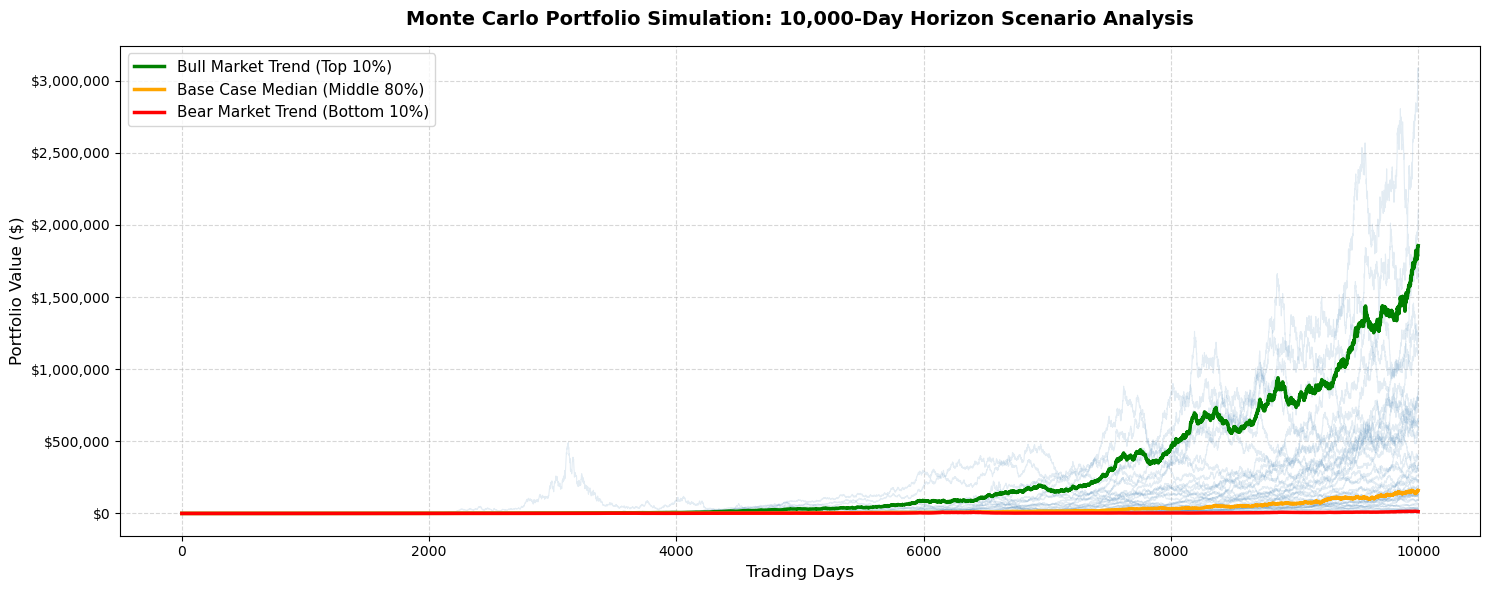

In [56]:
plt.figure(figsize=(15, 6))

# Plotting individual iterations or a subset of portfolio paths
# portfolio_paths shape is (10000, 50) -> 10,000 time steps, 50 iterations
time_axis = np.arange(portfolio_paths.shape[0])

# Plotting a subset of base paths in light grey/blue for background context
plt.plot(time_axis, portfolio_paths, color="steelblue", alpha=0.15, linewidth=0.8)

# Plotting specific scenario averages or sample paths to highlight outcomes
# Calculate mean trajectories for visual clarity
mean_bull_path = bull_paths.mean(axis=1)
mean_bear_path = bear_paths.mean(axis=1)
median_base_path = np.median(base_paths, axis=1)

plt.plot(time_axis, mean_bull_path, color="green", linewidth=2.5, label="Bull Market Trend (Top 10%)")
plt.plot(time_axis, median_base_path, color="orange", linewidth=2.5, label="Base Case Median (Middle 80%)")
plt.plot(time_axis, mean_bear_path, color="red", linewidth=2.5, label="Bear Market Trend (Bottom 10%)")

plt.title("Monte Carlo Portfolio Simulation: 10,000-Day Horizon Scenario Analysis", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

ax = plt.gca()
ax.yaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

In [50]:
# PHASE 5 - DERIVATIVES

In [52]:
def black_scholes_pricing(S, K, T, r, sigma, option_type="call"):
    # Calculate d1 and d2 components of the Black-Scholes formula
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        # Call option pricing formula
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        # Put option pricing formula
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be either 'call' or 'put'")

    return price

In [54]:
tickers = data.columns
strike_offset = 1.05  # e.g., Setting strike at 5% out-of-the-money
time_to_maturity = 1.0  # 1 year expiration

print(f"Black Scholes results: ")

for ticker in tickers:
    current_s = data[ticker].iloc[-1]
    strike_price = current_s * strike_offset  # Dynamic strike price based on current value
    aapl_volatility = annualized_standard_deviation_of_stocks[ticker]

    call_price = black_scholes_pricing(S=current_s, K=strike_price, T=time_to_maturity, r=risk_free_rate, sigma=aapl_volatility, option_type="call")

    put_price = black_scholes_pricing(S=current_s, K=strike_price, T=time_to_maturity, r=risk_free_rate, sigma=aapl_volatility, option_type="put")

    print(f"\nTicker: {ticker}")
    print(f"  Current Price (S):      ${current_s:,.2f}")
    print(f"  Strike Price (K):       ${strike_price:,.2f}")
    print(f"  Annualized Volatility:  {aapl_volatility:.4%}")
    print(f"  European Call Price:    ${call_price:,.2f}")
    print(f"  European Put Price:     ${put_price:,.2f}")

Black Scholes results: 

Ticker: AAPL
  Current Price (S):      $332.29
  Strike Price (K):       $348.90
  Annualized Volatility:  28.6774%
  European Call Price:    $37.33
  European Put Price:     $38.59

Ticker: MRNA
  Current Price (S):      $191.00
  Strike Price (K):       $200.55
  Annualized Volatility:  80.9745%
  European Call Price:    $59.81
  European Put Price:     $60.53

Ticker: LULU
  Current Price (S):      $93.46
  Strike Price (K):       $98.13
  Annualized Volatility:  41.0715%
  European Call Price:    $15.06
  European Put Price:     $15.41

Ticker: NKE
  Current Price (S):      $34.14
  Strike Price (K):       $35.85
  Annualized Volatility:  31.4503%
  European Call Price:    $4.21
  European Put Price:     $4.34


In [55]:
# Monte Carlo option pricing

In [57]:
strike_offset = 1.05  # Same 5% out-of-the-money strike offset used in Black-Scholes
time_to_maturity = 1.0  # 1 year expiration (10,000 steps roughly maps to your long-term model, but let's discount over T=1)

print(f"Comparison between Monte-Carlo and Black-Scholes results: ")

for i, ticker in enumerate(tickers):
    current_s = data[ticker].iloc[-1]
    strike_price = current_s * strike_offset

    # Extract terminal prices for this specific ticker from your simulation price_list
    # price_list shape is (10000, iterations, num_assets) -> terminal prices are at price_list[-1, :, i]
    terminal_prices = price_list[-1, :, i]

    # Calculating the European Call Payoffs at maturity: max(S_T - K, 0)
    call_payoffs = np.maximum(terminal_prices - strike_price, 0)

    # Discount the average payoff back to present value
    mc_call_price = np.exp(-risk_free_rate * time_to_maturity) * np.mean(call_payoffs)

    # Calculate European Put Payoffs at maturity: max(K - S_T, 0)
    put_payoffs = np.maximum(strike_price - terminal_prices, 0)
    mc_put_price = np.exp(-risk_free_rate * time_to_maturity) * np.mean(put_payoffs)

    # Retrieve the Black-Scholes price calculated in the previous step for comparison
    sigma = annualized_standard_deviation_of_stocks[ticker]
    bs_call = black_scholes_pricing(current_s, strike_price, time_to_maturity, risk_free_rate, sigma, "call")
    bs_put = black_scholes_pricing(current_s, strike_price, time_to_maturity, risk_free_rate, sigma, "put")

    print(f"\nTicker: {ticker}")
    print(f"  [Call] Black-Scholes: ${bs_call:,.2f} | Monte Carlo Simulated: ${mc_call_price:,.2f}")
    print(f"  [Put]  Black-Scholes: ${bs_put:,.2f} | Monte Carlo Simulated: ${mc_put_price:,.2f}")

Comparison between Monte-Carlo and Black-Scholes results: 

Ticker: AAPL
  [Call] Black-Scholes: $37.33 | Monte Carlo Simulated: $1,571,378.26
  [Put]  Black-Scholes: $38.59 | Monte Carlo Simulated: $0.00

Ticker: MRNA
  [Call] Black-Scholes: $59.81 | Monte Carlo Simulated: $9,063.19
  [Put]  Black-Scholes: $60.53 | Monte Carlo Simulated: $99.39

Ticker: LULU
  [Call] Black-Scholes: $15.06 | Monte Carlo Simulated: $202.75
  [Put]  Black-Scholes: $15.41 | Monte Carlo Simulated: $56.16

Ticker: NKE
  [Call] Black-Scholes: $4.21 | Monte Carlo Simulated: $4.16
  [Put]  Black-Scholes: $4.34 | Monte Carlo Simulated: $27.65
